## AGN Homework 3 – Cloudy PN \& BLR Simulations

**Cloudy** is a spectral simulation code designed to model the physical conditions and emission spectra of astronomical environments. The software calculates the ionization balance, chemical equilibrium, and thermal state of gas and dust under the influence of an external radiation source. We frequently utilize this tool to simulate regions near **Active Galactic Nuclei (AGN)** and regions of ionized hydrogen. It provides a comprehensive framework for predicting atomic and molecular emission lines across the entire electromagnetic spectrum, and is a widely recognized tool for its high accuracy in computing radiative transfer and thermodynamic processes in low density astrophysical plasmas.

In [1]:
%matplotlib inline
%config InlineBackend.figure_formats = ['svg']

import pandas as pd
import numpy as np
import matplotlib as mpl

import matplotlib.pyplot as plt

from scipy.optimize import curve_fit

plt.rcParams['figure.constrained_layout.use'] = True
plt.rcParams['legend.frameon'] = False
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams['axes.formatter.use_mathtext'] = True

cloudy_path = '../../../tutorial/Cloudy/source/cloudy.exe'

!echo "" | {cloudy_path[3:]} | awk 'NR<=3 || NR==6' | tr "*" " "

                                                          Cloudy 25.00
                                                         www.nublado.org

                                                             25Aug25                                      


### 1. Planetary Nebulae – Different Abundances

To get some intuition of how different abundances affect the resulting continuum spectra, we use the following inputs:

```
blackbody, T=1e5 K
luminosity total 38
radius 18
hden 5
sphere
abundances "{abn_grain}.abn"
iterate
print last iteration
save overview "{abn_grain}.ovr" last
save continuum "{abn_grain}.con" units microns last
```
Here, parameters in `{...}` are adopted to correspond to the default **Solar** or predefined **Planetary Nebula (PN)** elementary ratios, and modified such that dust and grains modeled for the **Interstellar Medium (ISM)** are included or excluded for both chemical compostions. Naming conventions are listed in the cell below, where we also define a helper function to read outputs and plot the different spectra for comparison:

In [2]:
abn_grain = ['pn_ism', 'pn_none', 'sol_ism', 'sol_none']

def pn_spec(abn_grain: str, l = 1e-2, r = 1e3, dust_fit = False, dl = 2e1, dr = 2e2):
    """
    Helper for reading and plotting synthetic planetary nebula spectra generated by Cloudy.

    Arguments:
        abn_grain: Identifies named abundances and grains settings.
        l: Left bound for zoomed plot window.
        r: Right bound for zoomed plot window.
        dust_fit: Toggles whether a modified black body dust emission fit to rolling median filter smoothed data is performed.
        dl: Left bound for dust emission bump to be fitted.
        dr: Right bound for dust emission bump to be fitted.

    Returns:
        con_df: Dataframe of continuum simulation data.
        ovr_df: Dataframe of structural overview file.
    """
    con_df = pd.read_table('pn/' + abn_grain + '.con').rename(columns={'#Cont  nu': 'lambda'})
    ovr_df = pd.read_table('pn/' + abn_grain + '.ovr').rename(columns={'#depth': 'depth'})

    fig, axs = plt.subplots(2, 1, figsize=[6,7])

    axs[0].plot(con_df['lambda'], con_df['total'], label='Emitted',
                c='k', ls='-', lw=1, alpha=1, zorder=100)
    axs[0].plot(con_df['lambda'], con_df['trans'], label='Transmitted',
                c='steelblue', ls='-', lw=1, alpha=2/3, zorder=10)
    axs[0].plot(con_df['lambda'], con_df['incident'], label='Incident',
                c='olivedrab', ls='--', lw=1, alpha=2/3, zorder=10)
    if dust_fit:
        axs[0].plot([], [], label='Dust', c='goldenrod', ls='--', lw=1, alpha=2/3, zorder=10)

    axs[0].set_xscale('log')
    axs[0].set_yscale('log')

    axs[0].set_xlim(np.min(con_df['lambda']), np.max(con_df['lambda']))

    axs[0].set_ylabel(r'$\lambda L_\lambda$ / erg s$^{-1}$')

    axs[0].legend()

    axs[1].plot(con_df['lambda'][(con_df['lambda'] > l) & (con_df['lambda'] < r)],
                con_df['total'][(con_df['lambda'] > l) & (con_df['lambda'] < r)],
                c='k', ls='-', lw=1, alpha=1, zorder=100)

    axs[1].set_xscale('log')
    axs[1].set_yscale('log')

    axs[1].set_xlim(l, r)
    axs[1].set_ylim(axs[1].set_ylim())

    axs[1].plot(con_df['lambda'][(con_df['lambda'] > l) & (con_df['lambda'] < r)],
                con_df['trans'][(con_df['lambda'] > l) & (con_df['lambda'] < r)],
                c='steelblue', ls='-', lw=1, alpha=2/3, zorder=10)
    axs[1].plot(con_df['lambda'][(con_df['lambda'] > l) & (con_df['lambda'] < r)],
                con_df['incident'][(con_df['lambda'] > l) & (con_df['lambda'] < r)],
                c='olivedrab', ls='--', lw=1, alpha=2/3, zorder=10)

    axs[1].set_xlabel(r'$\lambda$ / $\mu$m')
    axs[1].set_ylabel(r'$\lambda L_\lambda$ / erg s$^{-1}$')

    if dust_fit:
        def mod_bb(lam, T, b, C):
            C *= 1e48
            with np.errstate(over='ignore'):
                result = C / (lam**(4 + b) * (np.exp(14387.769 / (lam * T)) - 1))
            return result
        
        s = pd.Series(con_df['total'])

        window_size=151

        rolling_median = s.rolling(window=window_size, center=True, min_periods=1).median().to_numpy()
        
        rolling_std = s.rolling(window=window_size, center=True, min_periods=1).std().to_numpy()
        rolling_std[np.isnan(rolling_std)] = np.nanmedian(rolling_std)

        threshold_sigma = 2.0

        x = np.copy(con_df['lambda'])
        y = np.copy(con_df['total'])

        line_mask = y > (rolling_median + (threshold_sigma * rolling_std))

        y[line_mask] = rolling_median[line_mask]
        
        popt, pcov = curve_fit(mod_bb, x[(x > dl) & (x < dr)], y[(x > dl) & (x < dr)], p0=[75, 1.5, 1])

        print(f'Dust parameter erstimates:   T = {popt[0]:.2f} K   β = {popt[1]:.2f}')

        axs[1].plot(con_df['lambda'][(con_df['lambda'] > l) & (con_df['lambda'] < r)],
                mod_bb(con_df['lambda'][(con_df['lambda'] > l) & (con_df['lambda'] < r)], *popt),
                c='goldenrod', ls='--', lw=1, alpha=2/3, zorder=10)

    fig.text(s=f'Type: {abn_grain}', x=1.00, y=0.53, rotation=270, ha='center', va='center', transform=fig.transFigure)

    plt.show()
    plt.close()

    return con_df, ovr_df

We can now execute our **Cloudy** simulator to obtain the desired spectra with their associated computation runtimes:

#### a) PN Abundances & ISM Dust Grains

In [ ]:
%%time
%cd -q pn
!{cloudy_path} -r {abn_grain[0]}
%cd -q ..

CPU times: user 1.15 s, sys: 115 ms, total: 1.26 s
Wall time: 1min 13s


Dust parameter erstimates:   T = 70.94 K   β = 1.75


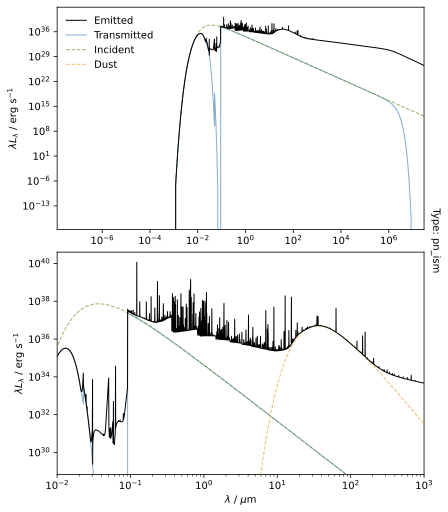

In [3]:
pn_ism_con, pn_ism_ovr = pn_spec(abn_grain[0], dust_fit=True)

#### b) PN Abundances & No Dust Grains

In [ ]:
%%time
%cd -q pn
!{cloudy_path} -r {abn_grain[1]}
%cd -q ..

CPU times: user 975 ms, sys: 87.5 ms, total: 1.06 s
Wall time: 59.6 s


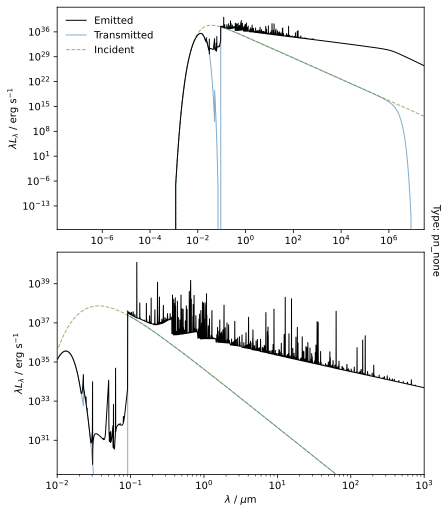

In [4]:
pn_none_con, pn_none_ovr = pn_spec(abn_grain[1])

#### c) Solar Abundances & ISM Dust Grains

In [ ]:
%%time
%cd -q pn
!{cloudy_path} -r {abn_grain[2]}
%cd -q ..

CPU times: user 943 ms, sys: 65 ms, total: 1.01 s
Wall time: 59.4 s


Dust parameter erstimates:   T = 72.73 K   β = 1.74


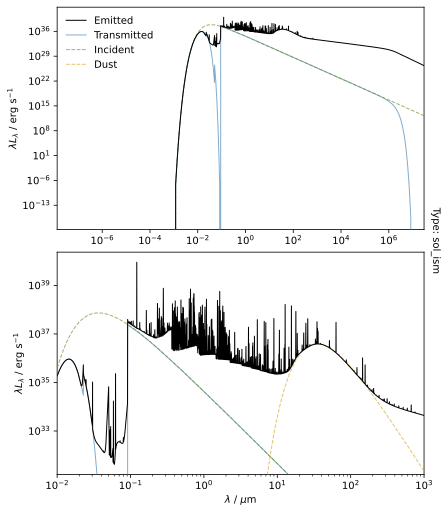

In [5]:
sol_ism_con, sol_ism_ovr = pn_spec(abn_grain[2], dust_fit=True)

#### d) Solar Abundances & No Dust Grains

In [ ]:
%%time
%cd -q pn
!{cloudy_path} -r {abn_grain[3]}
%cd -q ..

CPU times: user 791 ms, sys: 59.3 ms, total: 851 ms
Wall time: 47.1 s


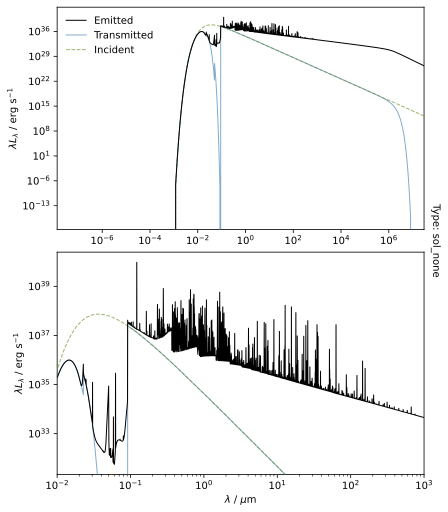

In [6]:
sol_none_con, sol_none_ovr = pn_spec(abn_grain[3])

Looking at the above plots, we can clearly see the separate effects of different chemical abundances and the presence of grains. Generally, our incident blackbody radiation field mimics a hot star with *T ~ 10<sup>5</sup> K* luminosity. This heats the surrounding gas to *T ~ 10<sup>4</sup> K* which quickly cools down for the outer layers, each of which has its own thermal emission. All of these tails add up to create a more shallow decrease in the long wavelength Rayleigh-Jeans regime. If there are dust grains present, they produce a prominent infrared bump with *T ~ 10<sup>1</sup> – 10<sup>2</sup> K* that is well described by a modified blackbody with a steeper slope for low energies from an emissivity correction. As for the abundance of elements, they affect mostly the density and intensity of emission and absorption lines. The planetary nebula model has fewer metals and lacks the lightest ones entirely, which makes lines sparse, whereas the sun is rich in light elements and therefore capable of producing dense line shapes.

### 2. Planetary Nebulae – Temperature Distributions

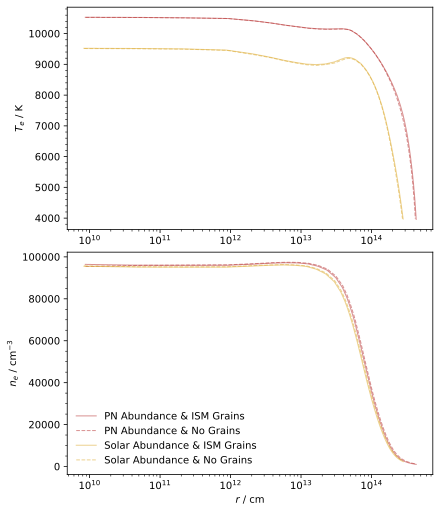

In [7]:
fig, axs = plt.subplots(2, 1, figsize=[6, 7])

axs[0].plot(pn_ism_ovr['depth'], pn_ism_ovr['Te'], c='firebrick', ls='-', lw=1, alpha=0.5)
axs[0].plot(pn_none_ovr['depth'], pn_none_ovr['Te'], c='firebrick', ls='--', lw=1, alpha=0.5)
axs[0].plot(sol_ism_ovr['depth'], sol_ism_ovr['Te'], c='goldenrod', ls='-', lw=1, alpha=0.5)
axs[0].plot(sol_none_ovr['depth'], sol_none_ovr['Te'], c='goldenrod', ls='--', lw=1, alpha=0.5)

axs[0].set_xscale('log')

axs[0].set_ylabel(r'$T_e$ / K')

axs[1].plot(pn_ism_ovr['depth'], pn_ism_ovr['eden'], c='firebrick', ls='-', lw=1, alpha=0.5,
        label='PN Abundance & ISM Grains')
axs[1].plot(pn_none_ovr['depth'], pn_none_ovr['eden'], c='firebrick', ls='--', lw=1, alpha=0.5,
        label='PN Abundance & No Grains')
axs[1].plot(sol_ism_ovr['depth'], sol_ism_ovr['eden'], c='goldenrod', ls='-', lw=1, alpha=0.5,
        label='Solar Abundance & ISM Grains')
axs[1].plot(sol_none_ovr['depth'], sol_none_ovr['eden'], c='goldenrod', ls='--', lw=1, alpha=0.5,
        label='Solar Abundance & No Grains')

axs[1].set_xscale('log')

axs[1].set_xlabel(r'$r$ / cm')
axs[1].set_ylabel(r'$n_e$ / cm$^{-3}$')

axs[1].legend()

plt.show()
plt.close()

As can be seen in this figure, the inner temperature of the illuminated face gradually decreases towards the outer edge. There is a slight bump visible in all cases where the depth is such that lower energy ionizing photons have been filtered by the inner regions and cooling effects are less effective due to lesser electron density. The higher abundance of efficient coolants such as carbon, nitrogen, and oxygen in the solar setting leads to a lower equilibrium temperature profile overall, while the planetary nebula is depleted of these elements, or they have formed dust grains and are therefore negligible as a gas component. The dust itself does not make a big difference in the overall shape of the distribution. To get more detailed insights into the heating and cooling contributors, one could save `heating` and `cooling` as well as `thermal` outputs during the simulation runs.

### 3. Broad Line Regions – Luminosity & Density

Now we start our physics setup from this configuration:

```
table power law
phi(H) 18.5
hden 10
stop column density 22
iterate to convergence
print last iteration
save overview "blr.ovr" last
save continuum "blr.con" units microns last
```

Since we want to compute line ratios over a whole range of ionizing flux and density values, we specify the sought for lines in `lines.dat` and run a grid:
```
table power law
phi(H) 18.5 grid range 18 to 24 step 0.5
hden 10 grid range 8 to 14 step 0.5
stop column density 22
iterate to convergence
print last iteration
save grid "blr.grd" last
save line list "blr.lin" "lines.dat" last
```

In [ ]:
%%time
%cd -q blr
!{cloudy_path} -r blr
%cd -q ..

CPU times: user 1min 47s, sys: 11.5 s, total: 1min 58s
Wall time: 2h 6min 36s
